# 1. Import and Install Dependencies

In [ ]:
!pip install tensorflow==2.4.1 tensorflow-gpu==2.4.1 opencv-python mediapipe sklearn matplotlib

In [1]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp

# 2. Keypoints using MP Holistic

In [2]:
mp_holistic = mp.solutions.holistic # Holistic model
mp_drawing = mp.solutions.drawing_utils # Drawing utilities

In [3]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # COLOR CONVERSION BGR 2 RGB
    image.flags.writeable = False                  # Image is no longer writeable
    results = model.process(image)                 # Make prediction
    image.flags.writeable = True                   # Image is now writeable 
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # COLOR COVERSION RGB 2 BGR
    return image, results

In [4]:
def draw_landmarks(image, results):
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACE_CONNECTIONS) # Draw face connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS) # Draw pose connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw right hand connections

In [5]:
def draw_styled_landmarks(image, results):
    # Draw face connections
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACE_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1), 
                             mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
                             ) 
    # Draw pose connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
                             ) 
    # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
                             ) 
    # Draw right hand connections  
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                             ) 

In [6]:
# KEEP LEFT HAND UP AND DONT REMOVE
cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)

        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

In [7]:
if results.left_hand_landmarks:
    print(len(results.left_hand_landmarks.landmark))
else:
    print("Left hand not detected.")

21


In [8]:
results

mediapipe.python.solution_base.SolutionOutputs

In [9]:
draw_landmarks(frame, results)

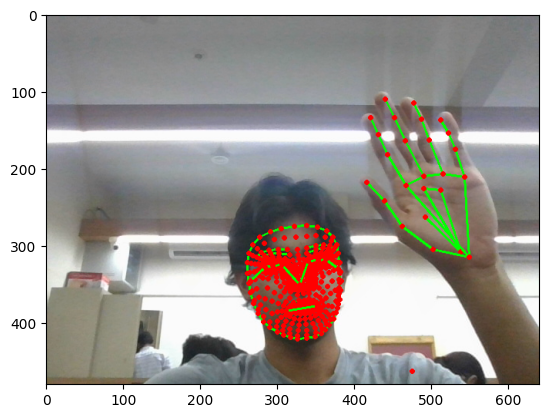

In [10]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

# 3. Extract Keypoint Values

In [11]:
len(results.left_hand_landmarks.landmark)

21

In [12]:
pose = []
for res in results.pose_landmarks.landmark:
    test = np.array([res.x, res.y, res.z, res.visibility])
    pose.append(test)

In [13]:
pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(132)
face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(1404)
lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)

In [14]:
face = (
    np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten()
    if results.face_landmarks
    else np.zeros(1404)
)


In [15]:
def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([pose, face, lh, rh])

In [16]:
result_test = extract_keypoints(results)

In [17]:
result_test

array([ 0.5141319 ,  0.73179567, -0.88326514, ...,  0.        ,
        0.        ,  0.        ])

In [18]:
468*3+33*4+21*3+21*3

1662

In [19]:
np.save('0', result_test)

In [20]:
np.load('0.npy')

array([ 0.5141319 ,  0.73179567, -0.88326514, ...,  0.        ,
        0.        ,  0.        ])

# 4. Setup Folders for Collection

In [21]:
# Path for exported data, numpy arrays
DATA_PATH = os.path.join('MP_Data') 

actions = np.array(['hard'])
label_map = {label:num for num, label in enumerate(actions)}
# FIFTY videos worth of data
no_sequences = 30 # MANDAR

# Videos are going to be 50 frames in length
sequence_length = 30

In [22]:
# hello
## 0
## 1
## 2
## ...
## 29
# thanks

# I love you

In [23]:
for action in actions: 
    for sequence in range(no_sequences):
        try: 
            os.makedirs(os.path.join(DATA_PATH, action, str(sequence)))
        except:
            pass

# 5. Collect Keypoint Values for Training and Testing

In [24]:
cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    
    # NEW LOOP
    # Loop through actions
    for action in actions:
        # Loop through sequences aka videos
        for sequence in range(no_sequences):
            # Loop through video length aka sequence length
            for frame_num in range(sequence_length):

                # Read feed
                ret, frame = cap.read()

                # Make detections
                image, results = mediapipe_detection(frame, holistic)
                 # print(results)

                # Draw landmarks
                draw_styled_landmarks(image, results)
                
                # NEW Apply wait logic
                if frame_num == 0: 
                    cv2.putText(image, 'STARTING COLLECTION', (120,200), 
                               cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255, 0), 4, cv2.LINE_AA)
                    cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15,12), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                    # Show to screen
                    cv2.imshow('OpenCV Feed', image)
                    cv2.waitKey(2000)
                else: 
                    cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15,12), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                    # Show to screen
                    cv2.imshow('OpenCV Feed', image)
                
                # NEW Export keypoints
                keypoints = extract_keypoints(results)
                npy_path = os.path.join(DATA_PATH, action, str(sequence), str(frame_num))
                np.save(npy_path, keypoints)

                # Break gracefully
                if cv2.waitKey(10) & 0xFF == ord('q'):
                    break
                    
    cap.release()
    cv2.destroyAllWindows()

In [26]:
# MANDAR RUN THIS AFTER ALL ITERATIONS ARE DONE
# DO NOT FORGET TO ADD IN PROPER SEQUENCE THE WORDS U HAVE MADE
# MANDAR U HAVE TO SAVE THIS ALSO AND THIS IS TO BE DONE AFTER 5 is completed entirely

# actions = np.array(['hello', 'my', 'name', 'is', 'mandar', 'gade', 'I', 'love', 'badminton'])
# label_map = {label:num for num, label in enumerate(actions)}

# 6. Preprocess Data and Create Labels and Features

In [27]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [28]:
label_map = {label:num for num, label in enumerate(actions)}

In [29]:
label_map

{'hello': 0,
 'my': 1,
 'name': 2,
 'mandar': 3,
 'i': 4,
 'deaf': 5,
 'mute': 6,
 'use': 7,
 'sign': 8,
 'language': 9,
 'want': 10,
 'data entry': 11,
 'job': 12,
 'completed': 13,
 'graduation': 14,
 'subject': 15,
 'computer': 16,
 'learn': 17,
 'typing': 18,
 'know': 19,
 'hindi': 20,
 'can': 21,
 'fast': 22,
 'do': 23,
 'work': 24,
 'carefully': 25,
 'one': 26,
 'year': 27,
 'experience': 28,
 'please': 29,
 'give': 30,
 'me': 31,
 'will': 32,
 'hard': 33,
 'thank you': 34,
 'chance': 35,
 'did': 36,
 'have': 37,
 'science': 38,
 'internet': 39,
 'word excel': 40,
 'english': 41}

In [30]:
import os
import numpy as np
from concurrent.futures import ThreadPoolExecutor

sequences, labels = [], []

def load_sequence(action, sequence):
    window = []
    for frame_num in range(sequence_length):
        res = np.load(os.path.join(DATA_PATH, action, str(sequence), f"{frame_num}.npy"))
        window.append(res)
    return window, label_map[action]

with ThreadPoolExecutor() as executor:
    futures = []
    for action in actions:
        for sequence in range(no_sequences):
            futures.append(executor.submit(load_sequence, action, sequence))

    for future in futures:
        window, label = future.result()
        sequences.append(window)
        labels.append(label)


FileNotFoundError: [Errno 2] No such file or directory: 'MP_Data\\thank you\\0\\0.npy'

In [ ]:
np.array(sequences).shape

In [131]:
np.array(labels).shape

(0,)

In [77]:
X = np.array(sequences)

In [78]:
X.shape

(450, 30, 1662)

In [79]:
y = to_categorical(labels).astype(int)

In [80]:
ya

array([[1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1]])

In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05)

In [82]:
y_test.shape

(23, 15)

# 7. Build and Train LSTM Neural Network

In [83]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 15021129917942104770
xla_global_id: -1
]


In [84]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import TensorBoard

In [85]:
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)

In [86]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, activation='relu', input_shape=(30,1662)))
model.add(LSTM(128, return_sequences=True, activation='relu'))
model.add(LSTM(64, return_sequences=False, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(actions.shape[0], activation='softmax'))

In [87]:
res = [.7, 0.2, 0.1]

In [88]:
actions[np.argmax(res)]

'hello'

In [89]:
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])

In [90]:
import tensorflow as tf
print("TF Version: ", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPUs available:", gpus)

TF Version:  2.11.0
GPUs available: []


In [91]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define model architecture
model = Sequential()
model.add(LSTM(64, return_sequences=True, activation='relu', input_shape=(30, 1662)))
model.add(Dropout(0.3))
model.add(LSTM(128, return_sequences=True, activation='relu'))
model.add(Dropout(0.3))
model.add(LSTM(64, return_sequences=False, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(actions.shape[0], activation='softmax'))  # actions should be a numpy array of shape (40,) for 40 classes

# Compile the model
optimizer = Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['categorical_accuracy'])

# Callbacks
checkpoint = ModelCheckpoint('best_model.h5', monitor='categorical_accuracy', save_best_only=True, mode='max', verbose=1)
earlystop = EarlyStopping(monitor='categorical_accuracy', patience=10, restore_best_weights=True, verbose=1)

# Train the model
history = model.fit(X_train, y_train, epochs=500, validation_data=(X_test, y_test), 
                    callbacks=[checkpoint, earlystop], batch_size=32)


Epoch 1/500
14/14 [==============================] - ETA: 0s - loss: 2.8911 - categorical_accuracy: 0.0749
Epoch 1: categorical_accuracy improved from -inf to 0.07494, saving model to best_model.h5
14/14 [==============================] - 6s 223ms/step - loss: 2.8911 - categorical_accuracy: 0.0749 - val_loss: 2.6955 - val_categorical_accuracy: 0.0870
Epoch 2/500
14/14 [==============================] - ETA: 0s - loss: 2.7274 - categorical_accuracy: 0.0890
Epoch 2: categorical_accuracy improved from 0.07494 to 0.08899, saving model to best_model.h5
14/14 [==============================] - 1s 87ms/step - loss: 2.7274 - categorical_accuracy: 0.0890 - val_loss: 2.7102 - val_categorical_accuracy: 0.1304
Epoch 3/500
14/14 [==============================] - ETA: 0s - loss: 2.7011 - categorical_accuracy: 0.0867
Epoch 3: categorical_accuracy did not improve from 0.08899
14/14 [==============================] - 1s 104ms/step - loss: 2.7011 - categorical_accuracy: 0.0867 - val_loss: 2.8173 - val_

In [93]:
history = model.fit(X_train, y_train,initial_epoch=29, epochs=100, validation_data=(X_test, y_test), 
                    callbacks=[checkpoint, earlystop], batch_size=32)

Epoch 30/100
14/14 [==============================] - ETA: 0s - loss: 1.9492 - categorical_accuracy: 0.3138
Epoch 30: categorical_accuracy did not improve from 0.32084
14/14 [==============================] - 1s 74ms/step - loss: 1.9492 - categorical_accuracy: 0.3138 - val_loss: 2.4133 - val_categorical_accuracy: 0.0435
Epoch 31/100
14/14 [==============================] - ETA: 0s - loss: 2.0479 - categorical_accuracy: 0.2670
Epoch 31: categorical_accuracy did not improve from 0.32084
14/14 [==============================] - 1s 72ms/step - loss: 2.0479 - categorical_accuracy: 0.2670 - val_loss: 2.0210 - val_categorical_accuracy: 0.2174
Epoch 32/100
14/14 [==============================] - ETA: 0s - loss: 1.8316 - categorical_accuracy: 0.3396
Epoch 32: categorical_accuracy improved from 0.32084 to 0.33958, saving model to best_model.h5
14/14 [==============================] - 1s 75ms/step - loss: 1.8316 - categorical_accuracy: 0.3396 - val_loss: 1.9024 - val_categorical_accuracy: 0.3043

In [52]:
history = model.fit(X_train, y_train,initial_epoch=100, epochs=150, validation_data=(X_test, y_test), 
                    callbacks=[checkpoint, earlystop], batch_size=32)

Epoch 101/150
14/14 [==============================] - ETA: 0s - loss: 0.5755 - categorical_accuracy: 0.7869
Epoch 101: categorical_accuracy did not improve from 0.79625
14/14 [==============================] - 1s 98ms/step - loss: 0.5755 - categorical_accuracy: 0.7869 - val_loss: 1.6336 - val_categorical_accuracy: 0.4783
Epoch 102/150
14/14 [==============================] - ETA: 0s - loss: 0.6119 - categorical_accuracy: 0.7845
Epoch 102: categorical_accuracy did not improve from 0.79625
14/14 [==============================] - 1s 93ms/step - loss: 0.6119 - categorical_accuracy: 0.7845 - val_loss: 1.3671 - val_categorical_accuracy: 0.4348
Epoch 103/150
14/14 [==============================] - ETA: 0s - loss: 0.5473 - categorical_accuracy: 0.8033
Epoch 103: categorical_accuracy improved from 0.79625 to 0.80328, saving model to best_model.h5
14/14 [==============================] - 1s 107ms/step - loss: 0.5473 - categorical_accuracy: 0.8033 - val_loss: 1.8466 - val_categorical_accuracy:

In [94]:
history = model.fit(X_train, y_train,initial_epoch=117, epochs=150, validation_data=(X_test, y_test), 
                    callbacks=[checkpoint, earlystop], batch_size=32)

Epoch 118/150
14/14 [==============================] - ETA: 0s - loss: 0.7308 - categorical_accuracy: 0.7073
Epoch 118: categorical_accuracy improved from 0.68384 to 0.70726, saving model to best_model.h5
14/14 [==============================] - 2s 108ms/step - loss: 0.7308 - categorical_accuracy: 0.7073 - val_loss: 0.9985 - val_categorical_accuracy: 0.6087
Epoch 119/150
14/14 [==============================] - ETA: 0s - loss: 0.7587 - categorical_accuracy: 0.7119
Epoch 119: categorical_accuracy improved from 0.70726 to 0.71194, saving model to best_model.h5
14/14 [==============================] - 1s 87ms/step - loss: 0.7587 - categorical_accuracy: 0.7119 - val_loss: 1.4234 - val_categorical_accuracy: 0.4783
Epoch 120/150
14/14 [==============================] - ETA: 0s - loss: 0.7321 - categorical_accuracy: 0.7377
Epoch 120: categorical_accuracy improved from 0.71194 to 0.73770, saving model to best_model.h5
14/14 [==============================] - 1s 80ms/step - loss: 0.7321 - categ

In [96]:
history = model.fit(X_train, y_train,initial_epoch=150, epochs=250, validation_data=(X_test, y_test), 
                    callbacks=[checkpoint, earlystop], batch_size=32)

Epoch 151/250
14/14 [==============================] - ETA: 0s - loss: 0.3340 - categorical_accuracy: 0.8665
Epoch 151: categorical_accuracy did not improve from 0.87119
14/14 [==============================] - 1s 101ms/step - loss: 0.3340 - categorical_accuracy: 0.8665 - val_loss: 1.7756 - val_categorical_accuracy: 0.4783
Epoch 152/250
14/14 [==============================] - ETA: 0s - loss: 0.2960 - categorical_accuracy: 0.8759
Epoch 152: categorical_accuracy improved from 0.87119 to 0.87588, saving model to best_model.h5
14/14 [==============================] - 1s 88ms/step - loss: 0.2960 - categorical_accuracy: 0.8759 - val_loss: 2.3262 - val_categorical_accuracy: 0.4783
Epoch 153/250
14/14 [==============================] - ETA: 0s - loss: 0.2874 - categorical_accuracy: 0.8829
Epoch 153: categorical_accuracy improved from 0.87588 to 0.88290, saving model to best_model.h5
14/14 [==============================] - 1s 85ms/step - loss: 0.2874 - categorical_accuracy: 0.8829 - val_loss:

In [98]:
history = model.fit(X_train, y_train,initial_epoch=150, epochs=170, validation_data=(X_test, y_test), 
                    callbacks=[checkpoint, earlystop], batch_size=32)

Epoch 151/170
14/14 [==============================] - ETA: 0s - loss: 0.2251 - categorical_accuracy: 0.8993
Epoch 151: categorical_accuracy did not improve from 0.92506
14/14 [==============================] - 1s 85ms/step - loss: 0.2251 - categorical_accuracy: 0.8993 - val_loss: 1.5482 - val_categorical_accuracy: 0.6522
Epoch 152/170
14/14 [==============================] - ETA: 0s - loss: 0.2616 - categorical_accuracy: 0.8759
Epoch 152: categorical_accuracy did not improve from 0.92506
14/14 [==============================] - 1s 79ms/step - loss: 0.2616 - categorical_accuracy: 0.8759 - val_loss: 1.1525 - val_categorical_accuracy: 0.6522
Epoch 153/170
14/14 [==============================] - ETA: 0s - loss: 0.2280 - categorical_accuracy: 0.8993
Epoch 153: categorical_accuracy did not improve from 0.92506
14/14 [==============================] - 1s 79ms/step - loss: 0.2280 - categorical_accuracy: 0.8993 - val_loss: 1.1525 - val_categorical_accuracy: 0.6087
Epoch 154/170
14/14 [=======

In [99]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_6 (LSTM)               (None, 30, 64)            442112    
                                                                 
 dropout_2 (Dropout)         (None, 30, 64)            0         
                                                                 
 lstm_7 (LSTM)               (None, 30, 128)           98816     
                                                                 
 dropout_3 (Dropout)         (None, 30, 128)           0         
                                                                 
 lstm_8 (LSTM)               (None, 64)                49408     
                                                                 
 dense_6 (Dense)             (None, 64)                4160      
                                                                 
 dense_7 (Dense)             (None, 32)               

# 8. Make Predictions

In [100]:
res = model.predict(X_test)

1/1 [==============================] - 1s 923ms/step


In [101]:
actions[np.argmax(res[4])]

'my'

In [102]:
actions[np.argmax(y_test[4])]

'i'

# 9. Save Weights

In [103]:
model.save('best_model_notfinal.h5')

In [104]:
model.load_weights('best_model.h5')

# 10. Evaluation using Confusion Matrix and Accuracy

In [105]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score

In [106]:
yhat = model.predict(X_test)

1/1 [==============================] - 0s 42ms/step


In [107]:
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()

In [108]:
multilabel_confusion_matrix(ytrue, yhat)

array([[[18,  1],
        [ 2,  2]],

       [[20,  2],
        [ 0,  1]],

       [[21,  2],
        [ 0,  0]],

       [[19,  0],
        [ 3,  1]],

       [[21,  0],
        [ 1,  1]],

       [[22,  0],
        [ 0,  1]],

       [[18,  2],
        [ 1,  2]],

       [[20,  1],
        [ 0,  2]],

       [[21,  0],
        [ 0,  2]],

       [[22,  0],
        [ 0,  1]],

       [[20,  0],
        [ 1,  2]]], dtype=int64)

In [109]:
accuracy_score(ytrue, yhat)

0.6521739130434783

# 11. Test in Real Time

In [114]:
colors = [(245,117,16), (117,245,16), (16,117,245)]
def prob_viz(res, actions, input_frame, colors):
    output_frame = input_frame.copy()
    for num, prob in enumerate(res):
        cv2.rectangle(output_frame, (0,60+num*40), (int(prob*100), 90+num*40), colors[num], -1)
        cv2.putText(output_frame, actions[num], (0, 85+num*40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)
        
    return output_frame

In [115]:
plt.figure(figsize=(18,18))
plt.imshow(prob_viz(res, actions, image, colors))

IndexError: list index out of range

<Figure size 1800x1800 with 0 Axes>

In [116]:
sequence.reverse()

In [117]:
len(sequence)

30

In [118]:
print(sequence.reverse())

None


In [119]:
np.expand_dims(X_test[0], axis=0).shape

(1, 30, 1662)

In [120]:
model.predict(np.expand_dims(X_test[0], axis=0))

1/1 [==============================] - 0s 30ms/step


array([[1.6302959e-08, 1.1580262e-11, 8.6737333e-07, 2.7694209e-06,
        3.1073988e-13, 1.7995378e-15, 1.1791067e-10, 1.0390075e-02,
        6.0397829e-06, 9.6478611e-01, 8.7448107e-06, 2.4799351e-02,
        3.8284265e-09, 5.8804635e-06, 9.8060774e-08]], dtype=float32)

In [121]:
# 1. New detection variables
sequence = []
sentence = []
threshold = 0.8

cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)
        
        # 2. Prediction logic
        keypoints = extract_keypoints(results)
#         sequence.insert(0,keypoints)
#         sequence = sequence[:30]
        sequence.append(keypoints)
        sequence = sequence[-30:]
        
        if len(sequence) == 30:
            res = model.predict(np.expand_dims(sequence, axis=0))[0]
            print(actions[np.argmax(res)])
            
            
        #3. Viz logic
            if res[np.argmax(res)] > threshold: 
                if len(sentence) > 0: 
                    if actions[np.argmax(res)] != sentence[-1]:
                        sentence.append(actions[np.argmax(res)])
                else:
                    sentence.append(actions[np.argmax(res)])

            if len(sentence) > 5: 
                sentence = sentence[-5:]

            # Viz probabilities
            image = prob_viz(res, actions, image, colors)
            
        cv2.rectangle(image, (0,0), (640, 40), (245, 117, 16), -1)
        cv2.putText(image, ' '.join(sentence), (3,30), 
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
        
        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

IndexError: list index out of range

In [74]:
cap.release()
cv2.destroyAllWindows()

In [75]:
res[np.argmax(res)] > threshold

IndexError: index 7 is out of bounds for axis 0 with size 5

In [76]:
(num_sequences,30,1662)

NameError: name 'num_sequences' is not defined

In [77]:
model.predict(np.expand_dims(X_test[0], axis=0))

1/1 [==============================] - 0s 40ms/step


array([[0.3266147 , 0.34119225, 0.33219305]], dtype=float32)

In [82]:
import cv2
import numpy as np
import mediapipe as mp
from keras.models import load_model
import matplotlib.pyplot as plt
import mediapipe as mp
FACEMESH_TESSELATION = mp.solutions.face_mesh_connections.FACEMESH_TESSELATION

AttributeError: module 'mediapipe.python.solutions' has no attribute 'face_mesh_connections'